# Imports

In [1]:
import pandas as pd
import numpy as np
from src.itp_rates import get_itp_cost
from src.mortgage import monthly_mortgage_payment, monthly_interest_payment, fixed_mortgage_schedule
import matplotlib.pyplot as plt
import os

# Data

In [2]:
project_root = os.getcwd()
os.chdir(project_root)

In [3]:
RELATIVE_PATH_TO_DATA = 'data/20250716sample.json'

In [4]:
df = pd.read_json(RELATIVE_PATH_TO_DATA)

In [5]:
df

,name,autonomous_community,property_price,notary_cost,registration_cost,administrative_cost,renovation_costs,furnishing_costs,real_estate_agency_costs,real_estate_personal_shopper_costs,...,non_payment_insurance,IBI,empty_period_percentage,other_annual_costs,mortgage_percentage_to_finance,mortgage_years,mortgage_interest_rate_percentage,mortgage_administrative_costs,mortgage_appraisal_costs,mortgage_broker_costs
0,"Test, Logroño",La Rioja,55000,500,250,0,3000,0,0,0,...,285,160,5,0,100,30,2,300,200,0


# Inputs

In [6]:
INITIAL_INVESTMENT_COST_COLUMNS = ['property_price',
                                   'notary_cost',
                                   'registration_cost',
                                   'administrative_cost',
                                   'renovation_costs',
                                   'furnishing_costs',
                                   'real_estate_agency_costs',
                                   'real_estate_personal_shopper_costs',
                                   'other_costs',
                                   'itp_costs',
                                   'mortgage_administrative_costs',
                                   'mortgage_appraisal_costs',
                                   'mortgage_broker_costs'
                                   ]

In [7]:
ANNUAL_OPERATIONAL_COSTS = ['house_insurance',
                            'life_insurance_for_mortgage',
                            'non_payment_insurance',
                            'IBI',
                            'maintenance_cost',
                            'empty_period_cost']

In [8]:
TAX_PERCENTAGE = 45

# Transformations

In [9]:
df['itp_costs'] = df.apply(lambda row: get_itp_cost(autonomous_community=row['autonomous_community'],                                                                                                   price=row['property_price']), axis=1)

In [10]:
df['initial_investment_cost_without_mortgage'] = df[INITIAL_INVESTMENT_COST_COLUMNS].sum(axis=1)

In [11]:
df['mortgage_quantity'] = df['property_price'] * df['mortgage_percentage_to_finance'] / 100
df['not_financed_quantity'] = df['initial_investment_cost_without_mortgage'] - df['mortgage_quantity']

In [12]:
df['monthly_mortgage_payment'] = df.apply(
    lambda row: monthly_mortgage_payment(principal=row['mortgage_quantity'],
                                         years=row['mortgage_years'],
                                         annual_interest_rate_percentage=row['mortgage_interest_rate_percentage']), axis=1)


df['monthly_interest_payment'] = df.apply(
    lambda row: monthly_interest_payment(principal=row['mortgage_quantity'],
                                         annual_interest_rate_percentage=row['mortgage_interest_rate_percentage']), axis=1)


df['monthly_principal_payment'] = df['monthly_mortgage_payment'] - df['monthly_interest_payment']


In [13]:
df['monthly_interest_payment']

0    91.666667
Name: monthly_interest_payment, dtype: float64

In [14]:
df['annual_mortgage_payment'] = df['monthly_mortgage_payment'] * 12
df['mortgage_interests_for_1_year'] = df['monthly_interest_payment'] * 12
df['mortgage_principal_for_1_year'] = df['monthly_principal_payment'] * 12

In [15]:
df['annual_rent'] = df['monthly_rent'] * 12
df['gross_yield_percentage'] = df['annual_rent'] / df['initial_investment_cost_without_mortgage'] * 100
df['maintenance_cost'] = df['maintenance_percentage'] / 100 * df['annual_rent']
df['empty_period_cost'] = df['empty_period_percentage'] / 100 * df['annual_rent']

In [16]:
df['annual_operational_costs'] = df[ANNUAL_OPERATIONAL_COSTS].sum(axis=1)

In [17]:
df['earnings_before_interest_and_taxes'] = df['annual_rent'] - df['annual_operational_costs']
df['earnings_before_taxes'] = df['earnings_before_interest_and_taxes'] - df['mortgage_interests_for_1_year']

In [18]:
df['earnings_after_taxes'] = df['earnings_before_taxes'] * (1 - TAX_PERCENTAGE / 100)
df['monthly_earnings_after_taxes'] = df['earnings_after_taxes'] / 12
df['net_yield_percentage'] = df['earnings_after_taxes'] / df['initial_investment_cost_without_mortgage'] * 100

In [19]:
df['annual_cashflow'] = df['earnings_after_taxes'] -  df['mortgage_principal_for_1_year']
df['monthly_cashflow'] = df['annual_cashflow'] / 12

In [20]:
df['return_on_capital_expenditure_percentage'] = df['annual_cashflow'] / df['not_financed_quantity'] * 100

# KPIs

In [21]:
df.columns

Index(['name', 'autonomous_community', 'property_price', 'notary_cost',
       'registration_cost', 'administrative_cost', 'renovation_costs',
       'furnishing_costs', 'real_estate_agency_costs',
       'real_estate_personal_shopper_costs', 'other_costs', 'monthly_rent',
       'annual_community_cost', 'maintenance_percentage', 'house_insurance',
       'life_insurance_for_mortgage', 'non_payment_insurance', 'IBI',
       'empty_period_percentage', 'other_annual_costs',
       'mortgage_percentage_to_finance', 'mortgage_years',
       'mortgage_interest_rate_percentage', 'mortgage_administrative_costs',
       'mortgage_appraisal_costs', 'mortgage_broker_costs', 'itp_costs',
       'initial_investment_cost_without_mortgage', 'mortgage_quantity',
       'not_financed_quantity', 'monthly_mortgage_payment',
       'monthly_interest_payment', 'monthly_principal_payment',
       'annual_mortgage_payment', 'mortgage_interests_for_1_year',
       'mortgage_principal_for_1_year', 'annual_ren

In [22]:
KPI_COLUMNS = ['gross_yield_percentage',
               'net_yield_percentage',
               'annual_cashflow',
               'monthly_cashflow',
               'return_on_capital_expenditure_percentage'
               ]

In [23]:
df[KPI_COLUMNS]

,gross_yield_percentage,net_yield_percentage,annual_cashflow,monthly_cashflow,return_on_capital_expenditure_percentage
0,9.033281,2.658479,338.01148,28.167623,4.172981


# Mortgage

In [24]:
[column for column in df.columns if 'mortgage' in column]

['life_insurance_for_mortgage',
 'mortgage_percentage_to_finance',
 'mortgage_years',
 'mortgage_interest_rate_percentage',
 'mortgage_administrative_costs',
 'mortgage_appraisal_costs',
 'mortgage_broker_costs',
 'initial_investment_cost_without_mortgage',
 'mortgage_quantity',
 'monthly_mortgage_payment',
 'annual_mortgage_payment',
 'mortgage_interests_for_1_year',
 'mortgage_principal_for_1_year']

In [25]:
principal = df['mortgage_quantity'].unique()[0]
years = df['mortgage_years'].unique()[0]
annual_interest_rate_percentage = df['mortgage_interest_rate_percentage'].unique()[0]

mortgage_schedule_df = fixed_mortgage_schedule(principal=principal,
                                               years=years,
                                               annual_interest_rate_percentage=annual_interest_rate_percentage)

mortgage_schedule_df

,pending_periods,monthly_payment,principal_payment,interest_payment,remaining_principal
0,360,0,0,0,55000
1,359,203,112,92,54888
2,358,203,112,91,54777
3,357,203,112,91,54665
4,356,203,112,91,54552
...,...,...,...,...,...
356,4,203,202,2,810
357,3,203,202,1,608
358,2,203,202,1,406
359,1,203,203,1,203


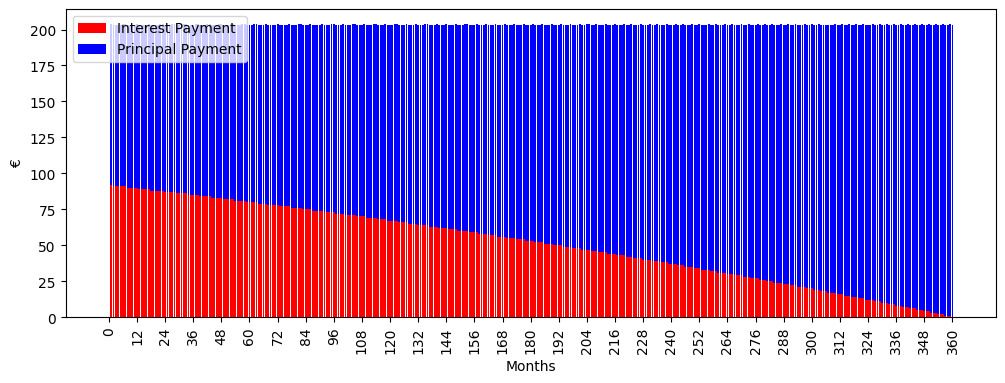

In [26]:
plt.figure(figsize=(12, 4))
plt.bar(mortgage_schedule_df.index, mortgage_schedule_df['interest_payment'], color='r', label='Interest Payment')
plt.bar(mortgage_schedule_df.index, mortgage_schedule_df['principal_payment'],
        bottom=mortgage_schedule_df['interest_payment'], color='b', label='Principal Payment')
plt.ylabel('€')
plt.xlabel('Months')
plt.xticks(np.arange(0, len(mortgage_schedule_df), 12), rotation=90)
plt.legend()
plt.show()